# Simple CNN Traffic Light Detector - From Scratch

**Study Project Features:**
- Custom CNN (no pretrained backbones)
- Single traffic light detection
- Ultra-small images (128x128) for fast training
- M1 GPU acceleration (MPS)
- Simple architecture for learning


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
import os
import multiprocessing
import wandb

# Set multiprocessing start method for macOS
# Note: In Jupyter, __name__ might not be '__main__', so we need a different approach
try:
    # This is needed for Windows/macOS
    multiprocessing.freeze_support()
except Exception:
    pass  # Ignore if it fails in Jupyter

# Always try to set the start method to 'spawn' for macOS compatibility
if multiprocessing.get_start_method(allow_none=True) != 'spawn':
    try:
        multiprocessing.set_start_method('spawn', force=True)
        print("Set multiprocessing start method to 'spawn'")
    except RuntimeError as e:
        print(f"Failed to set multiprocessing start method: {e}")
else:
    print("Multiprocessing start method is already set to 'spawn'")

# Setup device (M1 GPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize wandb
wandb.init(
    project="traffic-light-detection",
    config={
        "architecture": "SimpleCNN",
        "dataset": "traffic-lights",
        "epochs": 20,
        "batch_size": 64,
        "learning_rate": 0.001,
        "target_size": (128, 128),
    }
)
print("✅ Weights & Biases initialized for experiment tracking")


Set multiprocessing start method to 'spawn'
Using device: mps


wandb: Currently logged in as: kov-bog165 (kov-bog165-huindustry) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Weights & Biases initialized for experiment tracking


In [2]:
# Simple Dataset - Single traffic light per image
class SingleTrafficLightDataset(Dataset):
    def __init__(self, csv_file, target_size=(128, 128), is_train=True, cache_size=100):
        self.annotations = pd.read_csv(csv_file)
        self.target_size = target_size
        self.cache_size = cache_size
        self.cache = {}  # Simple LRU cache for images

        # Filter to only images that exist
        self.annotations = self.annotations[self.annotations['file_path'].apply(os.path.exists)]

        # Take first traffic light per image (simplified for study)
        self.annotations = self.annotations.groupby('file_path').first().reset_index()

        self.class_to_idx = {'go': 0, 'stop': 1, 'warning': 2, 'stopLeft': 3, 
                            'goForward': 4, 'goLeft': 5, 'warningLeft': 6}

        # Simple transforms
        if is_train:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            ])

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]
        img_path = row['file_path']

        # Check if image is in cache
        if img_path in self.cache:
            image = self.cache[img_path]
        else:
            # Load and compress to small size (128x128 for speed)
            image = Image.open(img_path).convert('RGB').resize(self.target_size, Image.BILINEAR)

            # Add to cache if not full
            if len(self.cache) < self.cache_size:
                self.cache[img_path] = image
            elif self.cache_size > 0:
                # Simple LRU: remove a random item (first one in dict)
                self.cache.pop(next(iter(self.cache)))
                self.cache[img_path] = image

        # Get single traffic light annotation
        target = torch.tensor([
            row['norm_center_x'],
            row['norm_center_y'],
            row['norm_width'],
            row['norm_height'],
            self.class_to_idx.get(row['Annotation tag'], 0)
        ], dtype=torch.float32)

        return self.transform(image), target

    def __getstate__(self):
        """Custom method for pickle - ensures dataset can be properly serialized for multiprocessing"""
        state = self.__dict__.copy()
        # Don't pickle the cache to avoid serialization issues
        state['cache'] = {}
        return state

    def __setstate__(self, state):
        """Custom method for pickle - ensures dataset can be properly deserialized for multiprocessing"""
        self.__dict__.update(state)

    def __reduce__(self):
        """Custom method for pickle - provides a more robust way to serialize the dataset"""
        # Store only the essential information needed to reconstruct the dataset
        # We'll initialize with an empty cache in the worker processes
        return (SingleTrafficLightDataset, (), self.__getstate__())


In [3]:
# Simple CNN from scratch - Educational
class SimpleCNN(nn.Module):
    """
    Custom CNN for single traffic light detection
    Input: 128x128x3 RGB image
    Output: 4 bbox coords + 7 class scores
    """
    def __init__(self, num_classes=7):
        super(SimpleCNN, self).__init__()

        # Convolutional feature extractor
        self.features = nn.Sequential(
            # Block 1: 128x128x3 -> 64x64x32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2: 64x64x32 -> 32x32x64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3: 32x32x64 -> 16x16x128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 4: 16x16x128 -> 8x8x256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # Bounding box regression head
        self.bbox_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 4),  # x, y, w, h
            nn.Sigmoid()  # Normalize to [0, 1]
        )

        # Classification head
        self.class_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes)  # 7 classes
        )

    def forward(self, x):
        # Extract features
        features = self.features(x)

        # Predict bbox and class separately
        bbox = self.bbox_head(features)
        class_scores = self.class_head(features)

        return bbox, class_scores

# Create model
model = SimpleCNN(num_classes=7).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model created from scratch!")
print(f"Total parameters: {total_params:,}")
print(f"Model size: ~{total_params * 4 / (1024**2):.2f} MB")

# Log model architecture to wandb
wandb.watch(model, log="all")


✅ Model created from scratch!
Total parameters: 8,812,107
Model size: ~33.62 MB


In [4]:
# Simple loss function
class DetectionLoss(nn.Module):
    def __init__(self, lambda_coord=5.0, lambda_class=1.0):
        super().__init__()
        self.lambda_coord = lambda_coord
        self.lambda_class = lambda_class
        self.mse = nn.MSELoss()
        self.ce = nn.CrossEntropyLoss()

    def forward(self, pred_bbox, pred_class, targets):
        """
        Args:
            pred_bbox: [batch, 4] - predicted bbox coordinates
            pred_class: [batch, num_classes] - predicted class scores
            targets: [batch, 5] - ground truth [cx, cy, w, h, class]
        """
        # Bounding box loss (MSE for coordinates)
        bbox_loss = self.mse(pred_bbox, targets[:, :4])

        # Classification loss (CrossEntropy)
        class_loss = self.ce(pred_class, targets[:, 4].long())

        # Combined loss
        total_loss = self.lambda_coord * bbox_loss + self.lambda_class * class_loss

        return total_loss, bbox_loss, class_loss

criterion = DetectionLoss()
print("✅ Simple loss function ready")


✅ Simple loss function ready


In [5]:
# Load datasets (128x128 images, single traffic light)
train_dataset = SingleTrafficLightDataset('train_annotations.csv', target_size=(128, 128), is_train=True)
val_dataset = SingleTrafficLightDataset('val_annotations.csv', target_size=(128, 128), is_train=False)

# Larger batch size for small images + use more workers
BATCH_SIZE = 64
# Calculate optimal number of workers (typically 4-6 is good for M1 Pro)
# Disable workers when using MPS as it can cause issues with multiprocessing
if hasattr(torch, 'backends') and hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    NUM_WORKERS = 0
    print("⚠️ Setting num_workers=0 as multiprocessing can cause issues with MPS devices")
else:
    NUM_WORKERS = min(6, os.cpu_count() - 1)  # Leave one core free for system tasks

# Configure DataLoader with multiple workers for better performance
# Disable pin_memory on MPS devices as it's not supported
use_pin_memory = False  # Always disable pin_memory to avoid issues with MPS
print("⚠️ Disabling pin_memory as it's not supported on MPS devices")

try:
    train_loader = DataLoader(
        train_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=True, 
        num_workers=NUM_WORKERS, 
        pin_memory=use_pin_memory, 
        persistent_workers=True if NUM_WORKERS > 0 else False
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=NUM_WORKERS, 
        pin_memory=use_pin_memory, 
        persistent_workers=True if NUM_WORKERS > 0 else False
    )
    print(f"✅ Using {NUM_WORKERS} worker processes for data loading")
except Exception as e:
    print(f"⚠️ Error setting up multiple workers: {e}")
    print("⚠️ Falling back to single-process data loading")
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                             num_workers=0, pin_memory=use_pin_memory, persistent_workers=False)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                           num_workers=0, pin_memory=use_pin_memory, persistent_workers=False)

print(f"✅ Datasets loaded:")
print(f"   Train: {len(train_dataset)} images")
print(f"   Val: {len(val_dataset)} images")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Batches per epoch: {len(train_loader)}")


⚠️ Setting num_workers=0 as multiprocessing can cause issues with MPS devices
⚠️ Disabling pin_memory as it's not supported on MPS devices
✅ Using 0 worker processes for data loading
✅ Datasets loaded:
   Train: 34950 images
   Val: 9566 images
   Batch size: 64
   Batches per epoch: 547


In [6]:
# Training setup
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Training loop
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    total_bbox_loss = 0
    total_class_loss = 0

    for images, targets in tqdm(loader, desc="Training"):
        images = images.to(device)
        targets = targets.to(device)

        # Forward pass
        pred_bbox, pred_class = model(images)
        loss, bbox_loss, class_loss = criterion(pred_bbox, pred_class, targets)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_bbox_loss += bbox_loss.item()
        total_class_loss += class_loss.item()

    return total_loss / len(loader), total_bbox_loss / len(loader), total_class_loss / len(loader)

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    total_bbox_loss = 0
    total_class_loss = 0

    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Validation"):
            images = images.to(device)
            targets = targets.to(device)

            pred_bbox, pred_class = model(images)
            loss, bbox_loss, class_loss = criterion(pred_bbox, pred_class, targets)

            total_loss += loss.item()
            total_bbox_loss += bbox_loss.item()
            total_class_loss += class_loss.item()

    return total_loss / len(loader), total_bbox_loss / len(loader), total_class_loss / len(loader)

print("✅ Ready to train")


✅ Ready to train


In [ ]:
# Train the model
NUM_EPOCHS = 20
history = {
    'train_loss': [], 'train_bbox': [], 'train_class': [],
    'val_loss': [], 'val_bbox': [], 'val_class': []
}
best_val_loss = float('inf')

print("="*60)
print("🚀 Starting Training")
print("="*60)

for epoch in range(NUM_EPOCHS):
    print(f"\n📍 Epoch {epoch+1}/{NUM_EPOCHS}")
    print("-"*60)

    # Train
    train_loss, train_bbox, train_class = train_epoch(model, train_loader, criterion, optimizer)

    # Validate
    val_loss, val_bbox, val_class = validate(model, val_loader, criterion)

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_bbox'].append(train_bbox)
    history['train_class'].append(train_class)
    history['val_loss'].append(val_loss)
    history['val_bbox'].append(val_bbox)
    history['val_class'].append(val_class)

    # Print results
    print(f"\n📊 Results:")
    print(f"   Train - Total: {train_loss:.4f} | BBox: {train_bbox:.4f} | Class: {train_class:.4f}")
    print(f"   Val   - Total: {val_loss:.4f} | BBox: {val_bbox:.4f} | Class: {val_class:.4f}")
    print(f"   LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Log metrics to wandb
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_bbox_loss": train_bbox,
        "train_class_loss": train_class,
        "val_loss": val_loss,
        "val_bbox_loss": val_bbox,
        "val_class_loss": val_class,
        "learning_rate": optimizer.param_groups[0]['lr']
    })

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model_path = 'best_model.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, model_path)
        # Log best model to wandb
        wandb.save(model_path)
        print(f"   ✅ Best model saved and logged to wandb!")

print("\n" + "="*60)
print(f"🎉 Training Complete! Best val loss: {best_val_loss:.4f}")
print("="*60)


🚀 Starting Training

📍 Epoch 1/20
------------------------------------------------------------


Training:  14%|█▍        | 78/547 [00:45<04:16,  1.83it/s]

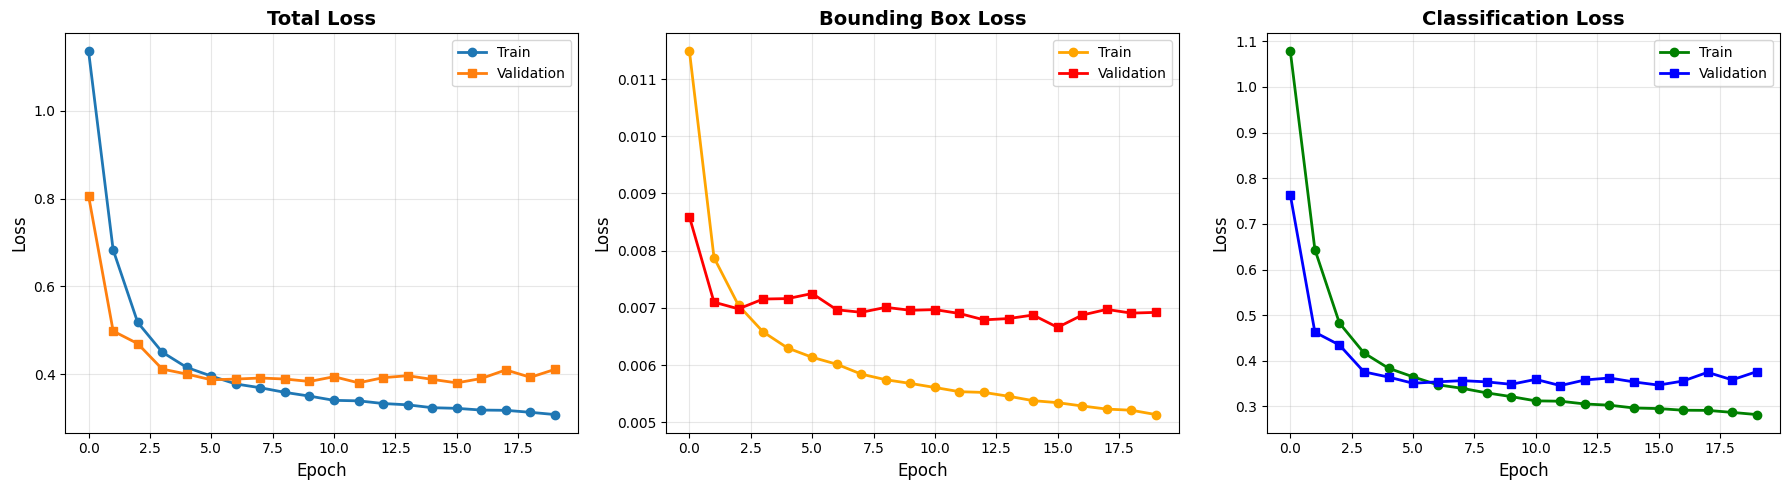

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total loss
axes[0].plot(history['train_loss'], label='Train', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Total Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# BBox loss
axes[1].plot(history['train_bbox'], label='Train', marker='o', linewidth=2, color='orange')
axes[1].plot(history['val_bbox'], label='Validation', marker='s', linewidth=2, color='red')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Bounding Box Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Classification loss
axes[2].plot(history['train_class'], label='Train', marker='o', linewidth=2, color='green')
axes[2].plot(history['val_class'], label='Validation', marker='s', linewidth=2, color='blue')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Loss', fontsize=12)
axes[2].set_title('Classification Loss', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
# Log the figure to wandb
wandb.log({"training_history": wandb.Image('training_history.png')})
plt.show()


Loaded model from epoch 16


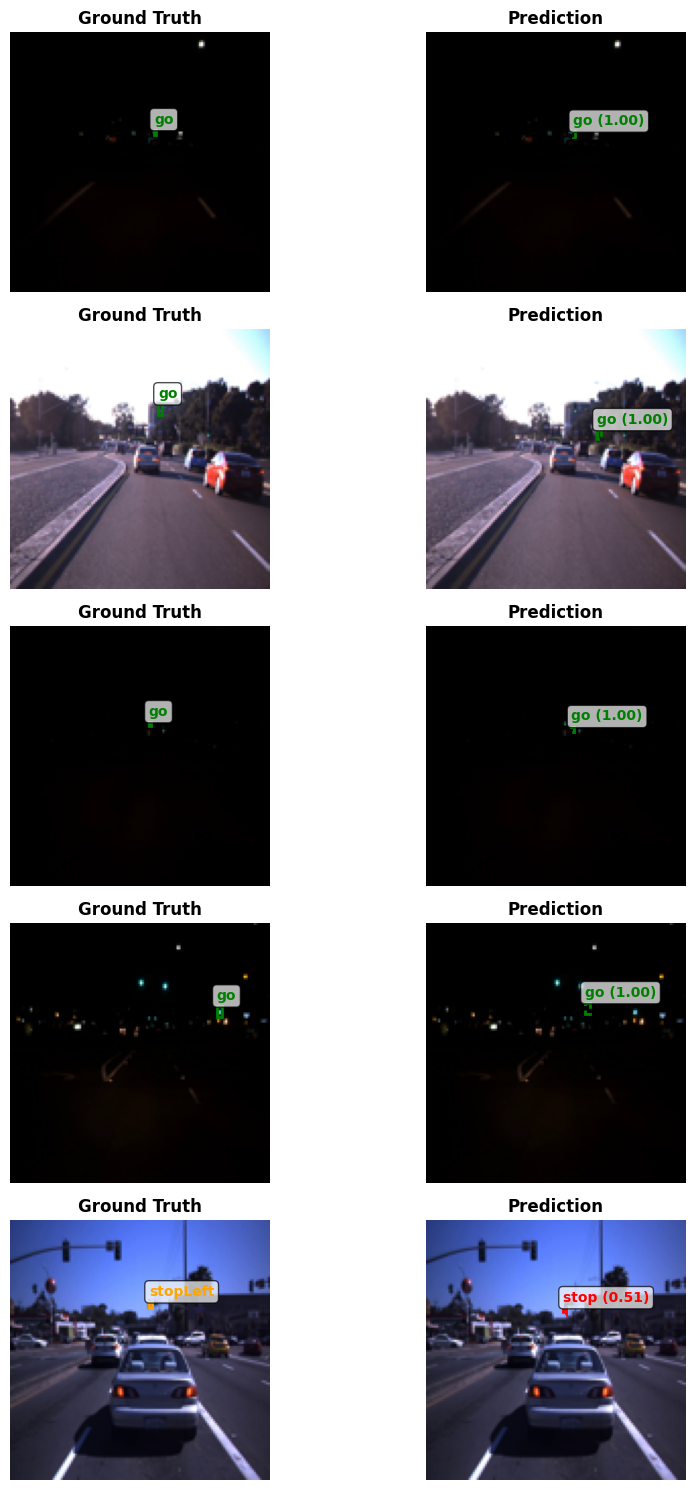

In [16]:
# Visualize predictions
def visualize_predictions(model, dataset, num_samples=5):
    model.eval()
    class_names = ['go', 'stop', 'warning', 'stopLeft', 'goForward', 'goLeft', 'warningLeft']
    colors = ['green', 'red', 'yellow', 'orange', 'cyan', 'blue', 'magenta']

    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 3*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, target = dataset[idx]

            # Load original image (128x128)
            row = dataset.annotations.iloc[idx]
            img_path = row['file_path']
            orig_img = Image.open(img_path).convert('RGB').resize((128, 128))

            # Predict
            pred_bbox, pred_class = model(image.unsqueeze(0).to(device))
            pred_bbox = pred_bbox[0].cpu().numpy()
            pred_class = torch.softmax(pred_class[0], dim=-1).cpu().numpy()

            # Ground truth
            axes[i, 0].imshow(orig_img)
            axes[i, 0].set_title('Ground Truth', fontsize=12, fontweight='bold')
            axes[i, 0].axis('off')

            cx, cy, w, h, cls = target
            x1, y1 = (cx - w/2) * 128, (cy - h/2) * 128
            rect = patches.Rectangle((x1, y1), w*128, h*128, linewidth=2, 
                                    edgecolor=colors[int(cls)], facecolor='none')
            axes[i, 0].add_patch(rect)
            axes[i, 0].text(x1, y1-3, class_names[int(cls)], 
                          color=colors[int(cls)], fontsize=10, weight='bold',
                          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

            # Prediction
            axes[i, 1].imshow(orig_img)
            axes[i, 1].set_title('Prediction', fontsize=12, fontweight='bold')
            axes[i, 1].axis('off')

            pred_cls = np.argmax(pred_class)
            confidence = np.max(pred_class)

            cx, cy, w, h = pred_bbox
            x1, y1 = (cx - w/2) * 128, (cy - h/2) * 128
            rect = patches.Rectangle((x1, y1), w*128, h*128, linewidth=2,
                                    edgecolor=colors[pred_cls], facecolor='none', linestyle='--')
            axes[i, 1].add_patch(rect)
            axes[i, 1].text(x1, y1-3, f'{class_names[pred_cls]} ({confidence:.2f})',
                          color=colors[pred_cls], fontsize=10, weight='bold',
                          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    # Log the predictions to wandb
    wandb.log({"predictions": wandb.Image('predictions.png')})
    plt.show()

# Load best model and visualize
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']+1}")

visualize_predictions(model, val_dataset, num_samples=5)


In [17]:
# Model Architecture Summary
print("\n" + "="*60)
print("📐 MODEL ARCHITECTURE")
print("="*60)
print(model)
print("\n" + "="*60)
print("📊 LAYER DETAILS")
print("="*60)

total_params = 0
trainable_params = 0

for name, param in model.named_parameters():
    num_params = param.numel()
    total_params += num_params
    if param.requires_grad:
        trainable_params += num_params
    print(f"{name:40s} | {str(param.shape):30s} | {num_params:>10,} params")

print("="*60)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / (1024**2):.2f} MB")
print("="*60)

# Finish wandb session
wandb.finish()
print("✅ Weights & Biases session completed")



📐 MODEL ARCHITECTURE
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1